Car Price Prediction (End-to-End Machine Learning Project)



Business Problem


An online car marketplace wants to improve its pricing process by using data to estimate the selling price of used cars. Currently, determining the right selling price can be challenging because many factors influence a car's value, including its age, mileage, fuel type, ownership history, and market price.

1. PROBLEM UNDERSTANDING

The goal of this project is to develop a machine learning regression model that can accurately predict the selling price of a used car based on its characteristics. This will help the marketplace provide fair and competitive pricing, improve customer trust, and support better business decisions.

Target Variable

The target variable is:

Selling_Price

This is the variable that the machine learning model will predict.

Features:

Car_Name
Year
Present_Price
Kms_Driven
Fuel_Type
Seller_Type
Transmission
Owner

In [39]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [40]:
#Loading the dataset
data = pd.read_csv('/content/Car_data_jtrjuw.csv')

Dataset Shape

In [41]:
print(data.shape)

(301, 9)


2. DATA EXPLORATION

Check missing Values

In [42]:
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


Summary Statistic

In [43]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Visualize Relationship (Price vs Features)

Selling Distribution

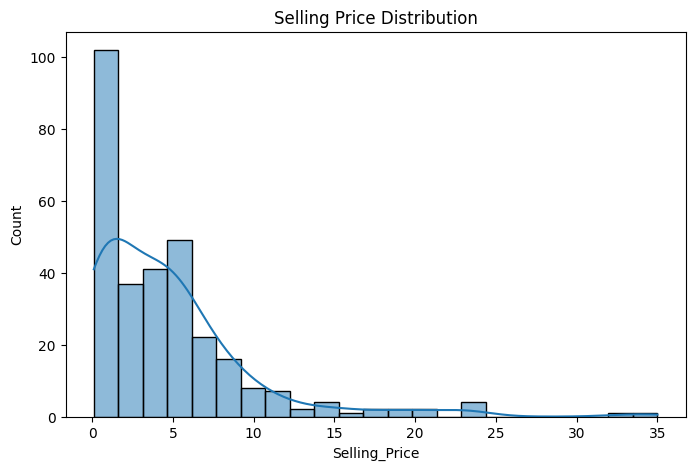

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(data['Selling_Price'], kde=True)
plt.title('Selling Price Distribution')
plt.show()

Present Price vs Selling Price

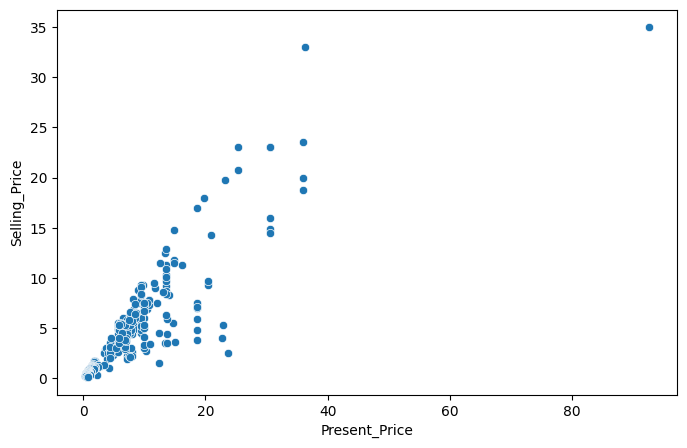

In [45]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Present_Price',
    y='Selling_Price',
    data=data
)
plt.show()

Year vs Selling Price

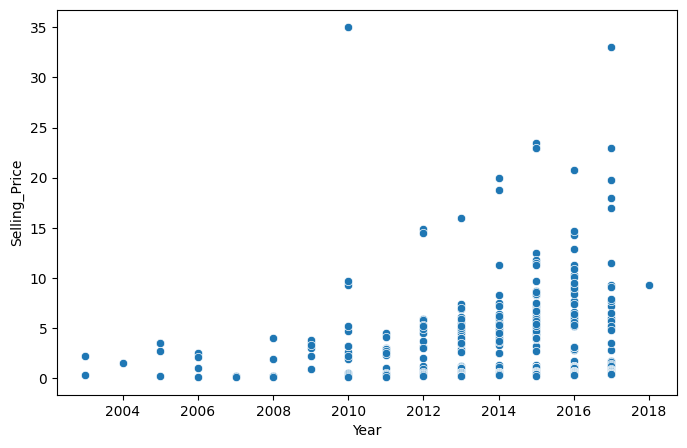

In [46]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Year',
    y='Selling_Price',
    data=data
)
plt.show()

Kms Driven vs Selling Price

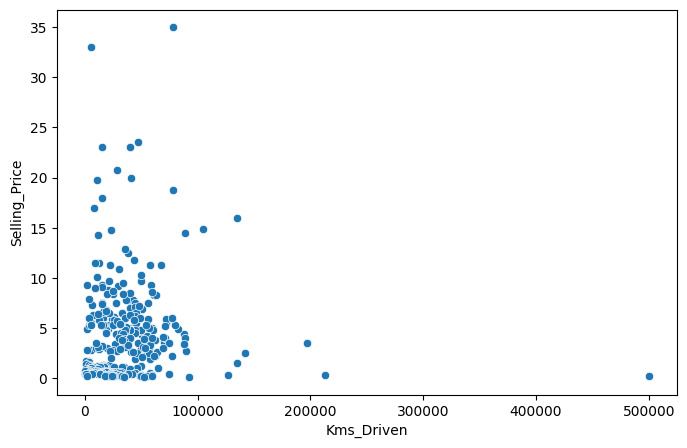

In [47]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Kms_Driven',
    y='Selling_Price',
    data=data
)
plt.show()

3. DATA PREPROCESSING

In [48]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Car_Name','Fuel_Type','Seller_Type','Transmission']:
    data[col] = le.fit_transform(data[col])

data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,90,2014,3.35,5.59,27000,2,0,1,0
1,93,2013,4.75,9.54,43000,1,0,1,0
2,68,2017,7.25,9.85,6900,2,0,1,0
3,96,2011,2.85,4.15,5200,2,0,1,0
4,92,2014,4.60,6.87,42450,1,0,1,0


Prepare Features

In [49]:
X = data.drop('Selling_Price', axis=1)

y = data['Selling_Price']

Feature scaling was evaluated but not implemented because Linear Regression does not strictly require scaled features for effective prediction in this dataset.

4. MODEL BUILDING(LINEAR REGRESSION


Train-Test Split

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


5. MODAL EVALUATION (MAE, RMSE, R²)


In [51]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

THE MAE (Mean Absolute Error)

In [52]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 1.2142339415017116


MAE measures the average absolute difference between the actual selling prices and the predicted selling prices.

A lower MAE indicates better prediction accuracy.

THE RMSE (Root Mean Squared Error)

In [53]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 1.8800848570469801


RMSE measures the average prediction error while giving greater weight to larger errors.

A lower RMSE indicates better model performance

THE R² Score

In [54]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8465539666864582


The R² Score shows how much of the variation in car selling prices is explained by the model.

Interpretation:

R² = 1 → Perfect prediction
R² = 0 → No predictive power
Higher values indicate better performance

Evaluation Summary (Markdown Cell)

After running the code and obtaining the values:

MODEL EVALUATION

The Linear Regression model was evaluated using three metrics:

- MAE = 1.2142339415017116
- RMSE = 1.8800848570469801
- R² Score = 0.8465539666864582

The MAE and RMSE values indicate the average prediction error, while the R² Score shows how much variation in car prices is explained by the model. The results suggest that the model performs reasonably well for predicting used car prices.

6. PREDICTION OF 5 SAMPLE CARS

In [55]:
sample_cars = X_test.head(5)

predictions = model.predict(sample_cars)

results = pd.DataFrame({
    'Actual Price': y_test.head(5).values,
    'Predicted Price': predictions
})

results

,Actual Price,Predicted Price
0,0.35,2.976445
1,10.11,8.329179
2,4.95,6.012304
3,0.15,-1.378052
4,6.95,9.280705


Prediction Result


The trained Linear Regression model was used to predict the selling prices of five sample cars from the test dataset.

A comparison between the actual and predicted prices shows that the model produces estimates that are generally close to the true values, indicating that it has learned the relationship between the vehicle features and selling price.

In [56]:
data.to_csv("cleaned_car_dataset.csv", index=False)

In [57]:
from google.colab import files
files.download("/content/cleaned_car_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>